## Section 1 - Map color bar

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.colors as mcolors

In [2]:
# Function to create a colormap from a AR6 text file containing RGB values
def create_colormap_from_txt(filepath, cmap_name="custom_colormap"):
    """
    Read RGB values from a text file and create a LinearSegmentedColormap.
    RGB value shoud be 0-1 range.
    """
    rgb_data = np.loadtxt(filepath)
    colormap = mcolors.LinearSegmentedColormap.from_list(cmap_name, rgb_data)
    return colormap

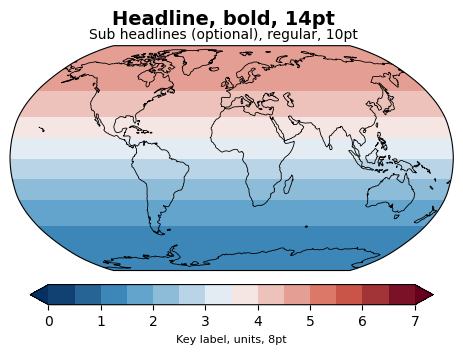

In [3]:
# Example dummy data
lon = np.linspace(-180, 180, 360)
lat = np.linspace(-90, 90, 180)
lon2d, lat2d = np.meshgrid(lon, lat)
data = 3 + 2 * np.sin(np.deg2rad(lat2d))  # dummy pattern
levels = np.linspace(0, 7, 15)

# Convert mm to inches and create figure with specified size
fig = plt.figure(figsize=(6.5, 3.65))  # Example size in inches (165mm x 92.8mm)

# Main headline (H1)
fig.suptitle(
    "Headline, bold, 14pt",
    fontsize=14,
    fontweight='bold',
    # y=0.97 # Adjust y to position the headline higher or lower
)

# Optional subheadline (H2)
fig.text(
    0.5, 0.90,
    "Sub headlines (optional), regular, 10pt",
    ha='center',
    fontsize=10,
)

# Map axis
ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()

# Plot data
cmap = create_colormap_from_txt("./continuous_colormaps_rgb_0-1/temp_div.txt")

im = ax.contourf(
    lon, lat, data,
    levels=levels,
    cmap=cmap,
    transform=ccrs.PlateCarree(),
    extend='both'
)

# Coastlines
ax.coastlines(linewidth=0.6)

# Colorbar
cbar = plt.colorbar(
    im,
    orientation='horizontal',
    pad=0.05,
    shrink=0.8
)
cbar.set_label("Key label, units, 8pt", fontsize=8)

plt.show()


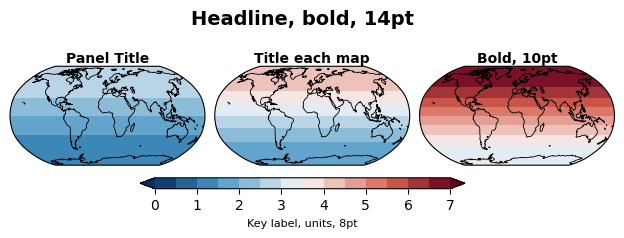

In [4]:
# Example dummy data
lon = np.linspace(-180, 180, 360)
lat = np.linspace(-90, 90, 180)
lon2d, lat2d = np.meshgrid(lon, lat)

data1 = 2 + np.sin(np.deg2rad(lat2d))
data2 = 3 + 1.5 * np.sin(np.deg2rad(lat2d))
data3 = 5 + 2 * np.sin(np.deg2rad(lat2d))

datasets = [data1, data2, data3]
panel_titles = ["Panel Title", "Title each map", "Bold, 10pt"]

levels = np.linspace(0, 7, 15)

# Create figure
fig = plt.figure(figsize=(6.5, 3.65))

# Headline (H1)
fig.text(0.5, 0.95,
         "Headline, bold, 14pt",
         ha='center',
         fontsize=14,
         fontweight='bold')

# Axes positions: left, bottom, width, height
lefts = [0.05, 0.365, 0.68]
width = 0.3
bottom = 0.25   # push maps upward
height = 0.9   # taller axes reduce gap above

for i in range(3):
    ax = fig.add_axes([lefts[i], bottom, width, height],
                      projection=ccrs.Robinson())
    ax.set_global()
    im = ax.contourf(lon, lat, datasets[i],
                     levels=levels,
                     cmap=cmap,
                     transform=ccrs.PlateCarree(),
                     extend='both')
    ax.coastlines(linewidth=0.6)
    ax.set_title(panel_titles[i], fontsize=10, fontweight='bold', pad=3)

# Colorbar
cax = fig.add_axes([0.25, 0.5, 0.5, 0.03])  # x, y, width, height
cbar = fig.colorbar(im, cax=cax, orientation='horizontal')
cbar.set_label("Key label, units, 8pt", fontsize=8)

plt.show()
